# Skenario 02 — Build Model Final Data Gabungan Pseudo-RUL

Notebook ini membaca hasil ABC dan PSO Skenario 02, membandingkan empat kandidat berdasarkan MSE cross-validation, melatih ulang seluruh kandidat pada data gabungan dengan target aktual dan pseudo-target, lalu menyimpan satu model terbaik. Jalankan notebook ABC dan PSO terlebih dahulu.

In [1]:
from pathlib import Path
import json
import shutil

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED = 42
SENSOR_COLS = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]
LIFE_COL = "Unit Lifetime (Hour)"
STATUS_COL = "Status"
TARGET_COL = "sisa jam"
UNIT_COL = "unit_id"
TARGET_SOURCE_COL = "target_source"
BREAK_COL = "estimated_break_hour"
FEATURE_COLS = SENSOR_COLS.copy()
COLUMN_ALIASES = {f"{col} (°C)": col for col in SENSOR_COLS[:4]}
DATA_FILE = "datas/vehicle-health-gabungan.xlsx"
REFERENCE_MODEL = "newcode/scenarios/01_RF_SVR_data_single/models/best_model.joblib"
MAX_RUL = 2550.0
PRIMARY_THRESHOLD = 250
SOURCE_FILES = {
    "unit_231": "datas/Data_Maluku_Utara_Unit_231_STATUS_FINAL.xlsx",
    "pt_amanah": "datas/Data_PT.Amanah_Critical_Break.xlsx",
    "unit_230": "datas/Data_Maluku_Utara_Unit_230_STATUS_FINAL.xlsx",
    "unit_228": "datas/Data_Maluku_Utara_Unit_228_STATUS_FINAL.xlsx",
}

## Muat data dan hasil optimasi

In [2]:
def find_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / DATA_FILE).exists():
            return path
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_FILE}")

def clean_data(raw):
    data = raw.rename(columns=COLUMN_ALIASES)[[*FEATURE_COLS, LIFE_COL, STATUS_COL]].copy()
    for col in FEATURE_COLS:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data[LIFE_COL] = pd.to_numeric(data[LIFE_COL], errors="coerce")
    data[STATUS_COL] = data[STATUS_COL].astype("string").str.strip().str.casefold()
    return data.dropna(subset=[*FEATURE_COLS, LIFE_COL, STATUS_COL]).reset_index(drop=True)

def prepare_data(root):
    data = clean_data(pd.read_excel(root / DATA_FILE))
    data["_row_order"] = np.arange(len(data))
    source_parts = []
    for unit_id, file_name in SOURCE_FILES.items():
        part = clean_data(pd.read_excel(root / file_name))
        part[UNIT_COL] = unit_id
        source_parts.append(part)
    source = pd.concat(source_parts, ignore_index=True)
    match_cols = [*FEATURE_COLS, LIFE_COL, STATUS_COL]
    if source.duplicated(match_cols).any():
        raise ValueError("Baris sumber tidak unik; identitas unit tidak dapat direkonstruksi dengan aman")
    data = data.merge(source[match_cols + [UNIT_COL]], on=match_cols, how="left", validate="one_to_one", sort=False)
    if data[UNIT_COL].isna().any() or len(data) != len(source):
        raise ValueError("Tidak seluruh baris data gabungan berhasil dipetakan ke unit sumber")
    data = data.sort_values("_row_order").drop(columns="_row_order").reset_index(drop=True)
    reference_path = root / REFERENCE_MODEL
    if not reference_path.exists():
        raise FileNotFoundError(f"Model referensi tidak ditemukan: {reference_path}. Jalankan Build Models Skenario 01.")
    reference_model = joblib.load(reference_path)
    break_hours = {}
    target_sources = {}
    for unit_id, group in data.groupby(UNIT_COL, sort=False):
        actual_break = group.loc[group[STATUS_COL].eq("break"), LIFE_COL].max()
        if pd.notna(actual_break):
            break_hours[unit_id] = float(actual_break)
            target_sources[unit_id] = "actual"
        else:
            last = group.sort_values(LIFE_COL).iloc[-1]
            predicted_rul = float(np.clip(reference_model.predict(last[FEATURE_COLS].to_frame().T)[0], 0, MAX_RUL))
            break_hours[unit_id] = float(last[LIFE_COL] + predicted_rul)
            target_sources[unit_id] = "estimated"
    data[BREAK_COL] = data[UNIT_COL].map(break_hours)
    data[TARGET_SOURCE_COL] = data[UNIT_COL].map(target_sources)
    data[TARGET_COL] = (data[BREAK_COL] - data[LIFE_COL]).clip(lower=0, upper=MAX_RUL)
    return data, break_hours

root = find_root()
scenario_dir = root / "newcode/scenarios/02_RF_SVR_data_gabungan_pseudo_RUL"
artifact_dir = scenario_dir / "artifacts"
model_dir = scenario_dir / "models"
model_dir.mkdir(parents=True, exist_ok=True)
data, break_hours = prepare_data(root)
candidates = {}
for optimizer in ["abc", "pso"]:
    for kind in ["rf", "svr"]:
        key = f"{optimizer}_{kind}"
        path = artifact_dir / key / "metrics.json"
        if not path.exists():
            raise FileNotFoundError(f"Hasil belum tersedia: {path}. Jalankan notebook optimasi terkait.")
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("data_scope") != "combined_pseudo_rul":
            raise ValueError(f"Artefak {key} bukan hasil data gabungan pseudo-RUL. Jalankan ulang notebook optimasi.")
        if item.get("feature_scope") != "sensor_only":
            raise ValueError(f"Artefak {key} masih memakai lifetime sebagai fitur. Jalankan ulang notebook optimasi.")
        if not item.get("threshold_metrics"):
            raise ValueError(f"Artefak {key} belum memiliki validasi ambang batas. Jalankan ulang notebook optimasi.")
        candidates[key] = item
comparison = pd.DataFrame(candidates).T.sort_values("cv_mse")
metric_cols = [
    "optimizer", "model", "cv_mse", "cv_rmse",
    "test_mse", "test_rmse", "test_mae", "test_r2", "objective_evaluations",
]
threshold_rows = []
for key, item in candidates.items():
    for row in item["threshold_metrics"]:
        threshold_rows.append({"candidate": key, **row})
threshold_comparison = pd.DataFrame(threshold_rows)
primary_cv = threshold_comparison.loc[
    threshold_comparison["scope"].eq("cv_oof")
    & threshold_comparison["threshold"].eq(PRIMARY_THRESHOLD)
].set_index("candidate")
display(comparison[metric_cols])
display(primary_cv[["tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]])

,optimizer,model,cv_mse,cv_rmse,test_mse,test_rmse,test_mae,test_r2,objective_evaluations
pso_rf,PSO,Random Forest,27813.524431,166.773872,20081.789581,141.710231,80.945273,0.967805,440
abc_rf,ABC,Random Forest,28524.390899,168.891654,20140.491106,141.917198,80.49469,0.967711,525
pso_svr,PSO,SVR,42243.676723,205.532666,29099.967433,170.587126,100.317792,0.953347,549
abc_svr,ABC,SVR,42244.517672,205.534712,29099.903507,170.586938,100.27415,0.953347,599


,tp,tn,fp,fn,accuracy,precision,recall,f1
candidate,,,,,,,,
abc_rf,140,2328,0,66,0.973954,1.00000,0.679612,0.809249
abc_svr,125,2321,7,81,0.965272,0.94697,0.606796,0.739645
pso_rf,142,2328,0,64,0.974743,1.00000,0.689320,0.816092
pso_svr,125,2321,7,81,0.965272,0.94697,0.606796,0.739645


## Latih seluruh kandidat dan simpan model terbaik

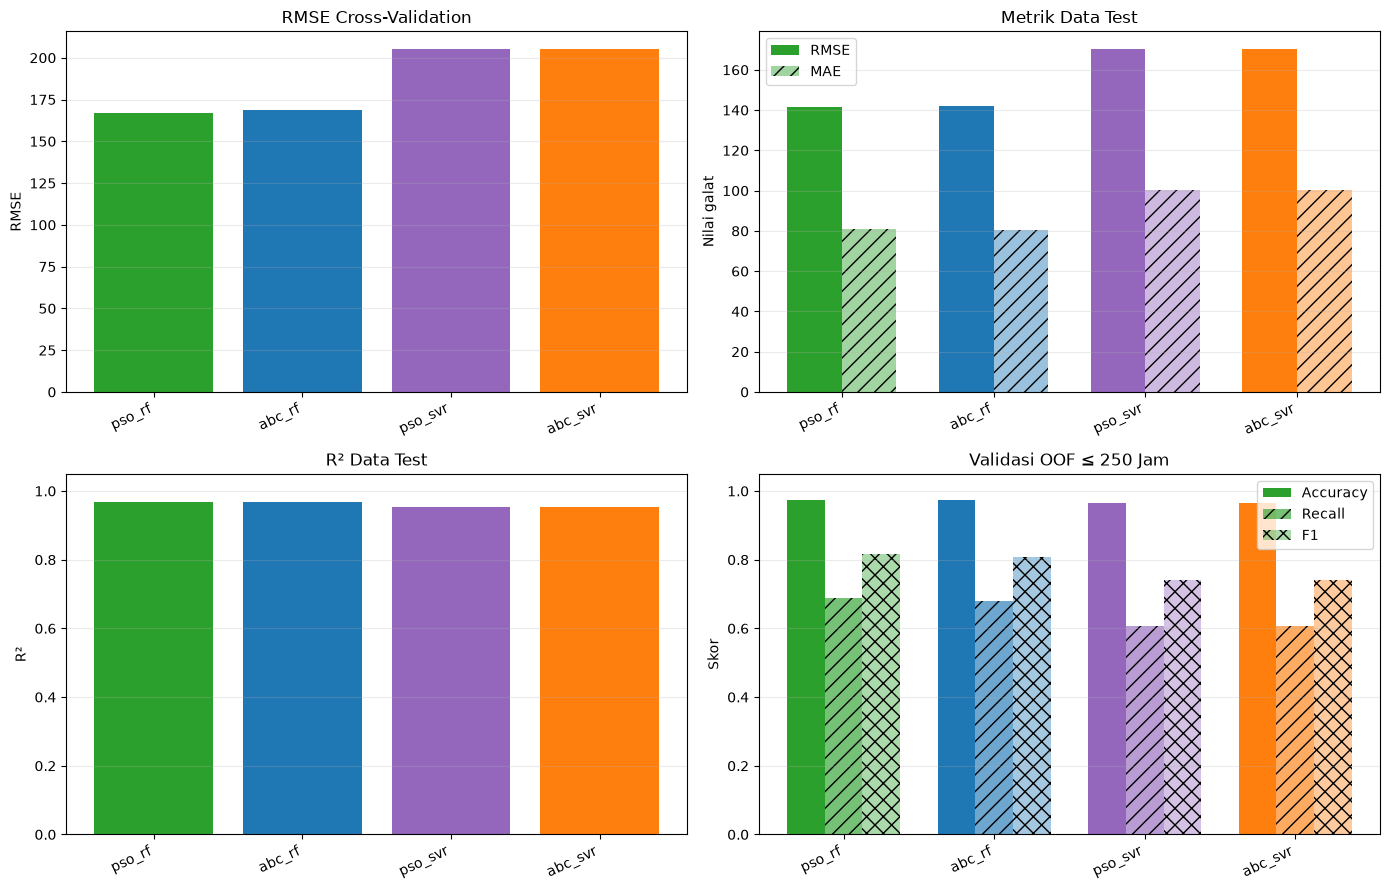

,optimizer,model,cv_mse,cv_rmse,test_mse,test_rmse,test_mae,test_r2,objective_evaluations,train_mse_diagnostic,train_rmse_diagnostic,train_mae_diagnostic,train_r2_diagnostic
candidate,,,,,,,,,,,,,
pso_rf,PSO,Random Forest,27813.524431,166.773872,20081.789581,141.710231,80.945273,0.967805,440,2659.290888,51.568313,27.507000,0.995801
abc_rf,ABC,Random Forest,28524.390899,168.891654,20140.491106,141.917198,80.49469,0.967711,525,2908.240274,53.928103,28.521159,0.995407
pso_svr,PSO,SVR,42243.676723,205.532666,29099.967433,170.587126,100.317792,0.953347,549,12406.973555,111.386595,54.471165,0.980407
abc_svr,ABC,SVR,42244.517672,205.534712,29099.903507,170.586938,100.27415,0.953347,599,12410.592567,111.402839,54.323027,0.980402


{'selected_model': 'pso_rf',
 'data_scope': 'combined_pseudo_rul',
 'feature_scope': 'sensor_only',
 'selection_metric': 'cv_mse',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'training_rows': 3168,
 'status_counts': {'normal': 1871, 'critical': 1296, 'break': 1},
 'unit_counts': {'pt_amanah': 2568,
  'unit_231': 200,
  'unit_230': 200,
  'unit_228': 200},
 'target_source_counts': {'actual': 2568, 'estimated': 600},
 'break_hours': {'unit_231': 54306.25769279888,
  'pt_amanah': 78637.0,
  'unit_230': 55006.6426331452,
  'unit_228': 55628.49338681787},
 'reference_model': 'newcode/scenarios/01_RF_SVR_data_single/models/best_model.joblib',
 'primary_threshold_hours': 250,
 'best_params': {'n_estimators': 201,
  'max_de

In [3]:
def make_model(kind, params):
    if kind == "rf":
        return RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    return Pipeline([("scale", StandardScaler()), ("svr", SVR(**params))])

def metric_values(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }

X, y = data[FEATURE_COLS], data[TARGET_COL]
model_paths = {}
train_metrics = {}
reload_checks = {}
training_predictions = data[[UNIT_COL, TARGET_SOURCE_COL, BREAK_COL, LIFE_COL, STATUS_COL, TARGET_COL]].copy()
training_predictions = training_predictions.rename(columns={TARGET_COL: "target_sisa_jam"})
for key, item in candidates.items():
    kind = key.rsplit("_", 1)[1]
    model = make_model(kind, item["best_params"])
    model.fit(X, y)
    predicted = model.predict(X)
    train_metrics[key] = metric_values(y, predicted)
    training_predictions[f"predicted_{key}"] = predicted
    path = model_dir / f"{key}.joblib"
    joblib.dump(model, path)
    loaded = joblib.load(path)
    reload_checks[key] = bool(np.allclose(predicted, loaded.predict(X)))
    model_paths[key] = str(path.relative_to(root))

if not all(reload_checks.values()):
    raise RuntimeError("Prediksi berubah setelah model dimuat ulang")

for key, values in train_metrics.items():
    for metric, value in values.items():
        comparison.loc[key, f"train_{metric}_diagnostic"] = value
comparison.index.name = "candidate"
comparison.reset_index().to_csv(model_dir / "model_comparison.csv", index=False)
threshold_comparison.to_csv(model_dir / "threshold_comparison.csv", index=False)
training_predictions.to_csv(model_dir / "training_predictions.csv", index=False)

best_key = min(candidates, key=lambda key: candidates[key]["cv_mse"])
best_path = model_dir / f"{best_key}.joblib"
shutil.copy2(best_path, model_dir / "best_model.joblib")
summary = {
    "selected_model": best_key,
    "data_scope": "combined_pseudo_rul",
    "feature_scope": "sensor_only",
    "selection_metric": "cv_mse",
    "target": TARGET_COL,
    "features": FEATURE_COLS,
    "training_rows": len(data),
    "status_counts": {str(key): int(val) for key, val in data[STATUS_COL].value_counts().items()},
    "unit_counts": {str(key): int(val) for key, val in data[UNIT_COL].value_counts().items()},
    "target_source_counts": {str(key): int(val) for key, val in data[TARGET_SOURCE_COL].value_counts().items()},
    "break_hours": break_hours,
    "reference_model": REFERENCE_MODEL,
    "primary_threshold_hours": PRIMARY_THRESHOLD,
    "best_params": candidates[best_key]["best_params"],
    "optimizer_results": candidates,
    "training_metrics_diagnostic": train_metrics,
    "primary_threshold_cv": primary_cv.reset_index().to_dict(orient="records"),
    "model_paths": model_paths,
    "reload_prediction_checks": reload_checks,
}
(model_dir / "build_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

colors = {"abc_rf": "tab:blue", "abc_svr": "tab:orange", "pso_rf": "tab:green", "pso_svr": "tab:purple"}
plot_df = comparison.sort_values("cv_rmse")
keys = plot_df.index.tolist()
x = np.arange(len(keys))
bar_colors = [colors[key] for key in keys]
primary_plot = primary_cv.reindex(keys)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].bar(x, plot_df["cv_rmse"], color=bar_colors)
axes[0, 0].set(title="RMSE Cross-Validation", ylabel="RMSE")
axes[0, 1].bar(x - 0.18, plot_df["test_rmse"], 0.36, color=bar_colors, label="RMSE")
axes[0, 1].bar(x + 0.18, plot_df["test_mae"], 0.36, color=bar_colors, alpha=0.45, hatch="//", label="MAE")
axes[0, 1].set(title="Metrik Data Test", ylabel="Nilai galat")
axes[0, 1].legend()
axes[1, 0].bar(x, plot_df["test_r2"], color=bar_colors)
axes[1, 0].set(title="R² Data Test", ylabel="R²", ylim=(0, 1.05))
axes[1, 1].bar(x - 0.25, primary_plot["accuracy"], 0.25, color=bar_colors, label="Accuracy")
axes[1, 1].bar(x, primary_plot["recall"], 0.25, color=bar_colors, alpha=0.65, hatch="//", label="Recall")
axes[1, 1].bar(x + 0.25, primary_plot["f1"], 0.25, color=bar_colors, alpha=0.4, hatch="xx", label="F1")
axes[1, 1].set(title=f"Validasi OOF ≤ {PRIMARY_THRESHOLD} Jam", ylabel="Skor", ylim=(0, 1.05))
axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xticks(x, keys, rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(model_dir / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
display(comparison[[*metric_cols, "train_mse_diagnostic", "train_rmse_diagnostic", "train_mae_diagnostic", "train_r2_diagnostic"]])
summary